# Regressão Logística

## 1. Introdução

A Regressão Logística é uma técnica estatística e de **Machine Learning Supervisionado** amplamente utilizada para resolver problemas de **classificação binária**. Diferente da Regressão Linear, que modela valores numéricos contínuos, a Regressão Logística calcula a probabilidade de uma observação pertencer a uma determinada classe (por exemplo, 0 ou 1, verdadeiro ou falso, spam ou não spam).

Neste material, exploraremos os fundamentos teóricos, a derivação matemática detalhada da função sigmoide, a construção da Máxima Verossimilhança, a função de custo por Entropia Cruzada, as métricas de avaliação de classificação e um exemplo prático completo.

## 2. O problema que queremos resolver

Em problemas de classificação binária, a variável resposta $y$ assume apenas dois valores discretos: $y_i \in \{0, 1\}$. 

Se tentássemos aplicar a Regressão Linear ($y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$ ou $y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip} + \varepsilon_i$) para prever uma variável binária, encontraríamos limitações matemáticas graves:
1. As previsões do modelo linear podem resultar em valores menores que 0 ou maiores que 1, o que viola diretamente os axiomas de probabilidade ($0 \le P(y) \le 1$).
2. A distribuição dos erros (resíduos) não seria normal e a variância não seria constante (violando a premissa de homocedasticidade, gerando heterocedasticidade severa), o que invalida testes de hipóteses estatísticos tradicionais.

Portanto, precisamos de uma função de mapeamento não linear que comprima qualquer valor real para o intervalo estrito $(0, 1)$.

## 3. A Função Sigmoide (Logística) e a Transformação Logit

Para restringir as saídas entre 0 e 1, mapeamos a saída da função linear utilizando uma função de ativação estritamente crescente e limitada, conhecida como **função logística** ou **função sigmoide**:

$$\Large
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

onde $z$ é a combinação linear das variáveis explicativas (parâmetros e atributos):

$$\Large
z_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip} = \mathbf{x}_i^T \boldsymbol{\beta}
$$

Substituindo $z$ na função sigmoide, obtemos a probabilidade estimada do evento $y_i = 1$ dado o vetor de características $\mathbf{x}_i$:

$$\Large
\hat{p}_i = \hat{y}_i = P(y_i = 1 | \mathbf{x}_i) = \sigma(\mathbf{x}_i^T \boldsymbol{\beta}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip})}}
$$

### 3.1. Fronteira de Decisão (*Decision Boundary*)

Para converter a probabilidade $\hat{p}_i$ na classificação final do algoritmo, definimos um valor de corte ou **limiar (*threshold*)**, que convencionalmente é $0{,}5$:

- Classifica-se como **$1$** se $\hat{p}_i \geq 0{,}5$
- Classifica-se como **$0$** se $\hat{p}_i < 0{,}5$

Matematicamente, $\sigma(z) \geq 0{,}5$ quando $z \geq 0$. Ou seja, a fronteira de decisão hiperplana é definida pelos pontos onde a combinação linear $\mathbf{X}_i\boldsymbol{\beta} = 0$.

### 3.2. A Derivação do Log-Odds (Logit)

Para entender como a regressão logística relaciona linearmente as probabilidades, partimos da probabilidade de sucesso $\hat{p}$:

$$\Large
\hat{p} = \frac{1}{1 + e^{-z}}
$$

Calculamos a probabilidade de fracasso ($1 - \hat{p}$):

$$\Large
1 - \hat{p} = 1 - \frac{1}{1 + e^{-z}} = \frac{(1 + e^{-z}) - 1}{1 + e^{-z}} = \frac{e^{-z}}{1 + e^{-z}} = \frac{1}{1 + e^{z}}
$$

A razão de chances (*odds*) é a divisão entre a probabilidade de sucesso e a de fracasso:

$$\Large
\frac{\hat{p}}{1 - \hat{p}} = \frac{\frac{1}{1 + e^{-z}}}{\frac{e^{-z}}{1 + e^{-z}}} = \frac{1}{e^{-z}} = e^z
$$

Aplicando o logaritmo natural ($\ln$) em ambos os lados, isolamos a combinação linear $z$ (a função **logit**):

$$\Large
\operatorname{logit}(\hat{p}) = \ln\left(\frac{\hat{p}}{1 - \hat{p}}\right) = z = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}
$$

Isso demonstra formalmente que, embora a probabilidade seja não linear em relação aos parâmetros, o **log-odds** possui uma relação estritamente linear com as variáveis explicativas.

**O que isso significa de forma prática?**

- Cada coeficiente numérico estimado $\beta_j$ representa a mudança no log-odds da classe positiva ocasionada pelo aumento de uma unidade em $x_j$, assumindo que as outras variáveis permanecem constantes.
- Quando exponenciamos um coeficiente, $e^{\beta_j}$, obtemos o **fator multiplicativo** da chance (*odds ratio*). Se $e^{\beta_j} = 1{,}5$, significa que a chance (*odds*) do evento aumenta em $50\%$ para cada acréscimo unitário em $x_j$.

## 4. Estimação de Parâmetros: Máxima Verossimilhança e Função de Custo

Na Regressão Linear, otimizamos os parâmetros usando o método da Soma dos Erros Quadráticos (SSE). Se usarmos o SSE na Regressão Logística com a função sigmoide, a função de custo resultante será **não-convexa**, cheia de mínimos locais que corrompem a descida do gradiente.

Para encontrar a melhor curva sigmoide, adotamos uma abordagem probabilística: a **Estimação por Máxima Verossimilhança (*MLE - Maximum Likelihood Estimation*)**. O objetivo é encontrar o vetor de parâmetros $\boldsymbol{\beta}$ que maximiza a probabilidade conjunta da observação do nosso conjunto de dados target de treinamento $\mathbf{y}$ dado as features de treinamento $\mathbf{x}$.

### 4.1. Construção da Função de Verossimilhança

Para uma única observação $i$, a distribuição de Bernoulli define a probabilidade de observar $y_i$ dado $\mathbf{x}_i$ como:

$$\Large
P(y_i | \mathbf{x}_i; \boldsymbol{\beta}) = \hat{y}_i^{y_i} (1 - \hat{y}_i)^{1 - y_i}
$$
onde $\hat{y}_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta})$, e $\hat{y}_i$ pode ser compreendido como a probabilidade de sucesso (e de fato é, pois é calculado considerando Y = 1)

Assumindo que todas as $n$ amostras são independentes e identicamente distribuídas (i.i.d.), a função de verossimilhança total $L(\boldsymbol{\beta})$ é o produto das probabilidades individuais:

$$\Large
L(\boldsymbol{\beta}) = \prod_{i=1}^{n} \hat{y}_i^{y_i} (1 - \hat{y}_i)^{1 - y_i}
$$

Como trabalhar com produtos é computacionalmente difícil e propenso a *underflow* numérico, aplicamos o logaritmo natural para converter o produto em uma soma (Log-Verossimilhança):

$$\Large
\ln L(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]
$$

### 4.2. Função de Custo: Entropia Cruzada Binária (Binary Cross-Entropy)

O objetivo da otimização é **maximizar** a log-verossimilhança. Em Machine Learning, convencionou-se estruturar problemas como minimização de custo. Multiplicando a log-verossimilhança por $-\frac{1}{n}$, obtemos a função de custo de **Entropia Cruzada Binária**:

$$\Large
J(\boldsymbol{\beta}) = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]
$$

Ao minimizar essa função, estaremos maximizando a log-verossimilhança.
Essa função matemática é **estritamente convexa** no espaço de parâmetros $\boldsymbol{\beta}$, garantindo que qualquer algoritmo de descida de gradiente converja para o único mínimo global.

![Visualização da função de custo da Regressão Logística](../images/logistic-regression.png)

## 5. Otimização por Gradiente Descendente

Para encontrar o vetor de parâmetros $\boldsymbol{\beta}$ que minimiza $J(\boldsymbol{\beta})$, utilizamos o algoritmo iterativo do **Gradiente Descendente**. 

Aplicando o cálculo diferencial (regra da cadeia) para encontrar a derivada parcial da função de custo em relação a um parâmetro específico $\beta_j$:

$$\Large
\frac{\partial J}{\partial \beta_j} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) x_{ij} =  \frac{1}{n} \sum_{i=1}^{n} \left( \sigma(\mathbf{x}_i^T \boldsymbol{\beta}) - y_i \right) x_{ij}
$$

Notavelmente, embora a função sigmoide seja altamente não linear, sua derivada combinada com a entropia cruzada resulta em uma expressão de gradiente idêntica à da regressão linear. Importante notar que o termo determinante para que as derivadas parciais sejam diferentes é o termo $x_{ij}$, considerando a característica específica $j$ das observações $i$.

Para o **intercepto** (ou viés, $\beta_0$), adota-se a convenção de que $x_{i0} = 1$ para todas as observações $i$. Com isso, sua derivada parcial simplifica-se para a média direta dos erros de predição:

$$\Large
\frac{\partial J}{\partial \beta_0} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)
$$

A regra de atualização iterativa dos pesos em cada época é:

$$\Large
\beta_j^{(novo)} = \beta_j - \alpha \frac{\partial J}{\partial \beta_j}
$$

onde $\alpha > 0$ representa a taxa de aprendizado (*learning rate*), controlando o tamanho do passo no espaço de otimização.

### 5.1. Otimização por Gradiente Descendente Matricial

Escrevendo de forma matricial condensada — onde a matriz de observações e features $\mathbf{X}$ inclui uma primeira coluna preenchida com $1's$ para incorporar o **intercepto** $\beta_0$ —, o vetor gradiente completo torna-se:

$$\Large
\nabla J = \frac{1}{n} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})
$$

Para cada iteração $k$, a etapa de ajuste contra o gradiente na direção do ponto de mínimo é dada por:

$$\Large
\boldsymbol{\beta}^{(k+1)} = \boldsymbol{\beta}^{(k)} - \alpha \nabla J
$$

onde $\alpha > 0$ representa a taxa de aprendizado (*learning rate*), controlando o tamanho do passo no espaço de otimização.

*Nota*: bibliotecas robustas de Machine Learning em Python (como o *scikit-learn*) utilizam internamente algoritmos numéricos ainda mais sofisticados e rápidos em convergência em comparação ao Gradient Descent tradicional, como L-BFGS (*Limited-memory Broyden–Fletcher–Goldfarb–Shanno*) ou *Newton-Raphson*, que se utilizam do inverso da Matriz Hessiana.

## 6. Regularização (Lasso L1 e Ridge L2)

A **regularização** é aplicada para controlar a complexidade do modelo e mitigar o sobreajuste (*overfitting*), adicionando um termo de penalização à função de custo de Entropia Cruzada:

$$\Large
\text{Custo Regularizado} = J(\boldsymbol{\beta}) + \lambda \,\text{penalização}(\boldsymbol{\beta})
$$

- **Ridge (L2)**: penaliza a soma dos quadrados dos coeficientes estruturais ($\sum_{j=1}^p \beta_j^2$), encolhendo os valores dos parâmetros em direção a zero sem eliminá-los.
- **Lasso (L1)**: penaliza a soma dos valores absolutos dos coeficientes ($\sum_{j=1}^p |\beta_j|$), o que pode zerar completamente coeficientes de variáveis irrelevantes, exercendo seleção automática de atributos (*feature selection*).

**Atenção ao `scikit-learn`:** ao contrário de implementações matemáticas teóricas que usam o parâmetro de intensidade regularizadora $\lambda$, a biblioteca `LogisticRegression` em Python impõe uma regularização em relação inversa parametrizada por `C`. 

$$\Large
C = \frac{1}{\lambda}
$$
Valores pequenos de `C` resultam em regularização forte e restritiva; valores altos relaxam o modelo, alinhando-se muito intimamente aos dados de treino.

## 7. Métricas de Avaliação para Classificação

Em problemas de classificação, a acurácia isolada pode ser enganosa (especialmente em bases desbalanceadas). Utilizamos um conjunto complementar de métricas:

### 7.1. Matriz de Confusão

Forma tabular para cruzar o cenário preditivo com a realidade de classes.

- **VP (Verdadeiros Positivos)**: previstos como positivos e são reais positivos.
- **VN (Verdadeiros Negativos)**: previstos como negativos e são reais negativos.
- **FP (Falsos Positivos - Erro Tipo I)**: previstos como positivos, mas são reais negativos.
- **FN (Falsos Negativos - Erro Tipo II)**: previstos como negativos, mas são reais positivos.

| | Previsto Positivo (1) | Previsto Negativo (0) |
|---|---|---|
| **Real Positivo (1)** | Verdadeiro Positivo (TP) | Falso Negativo (FN) |
| **Real Negativo (0)** | Falso Positivo (FP) | Verdadeiro Negativo (TN) |

### 7.2. Principais Indicadores
- **Acurácia (Accuracy)**: mede a pureza total global de inferências certas: $$\Large \frac{VP + VN}{VP + VN + FP + FN}$$
- **Precisão (Precision)**: Preocupa-se com os Falsos Positivos. Se o modelo diz "classe 1", quão confiável ele é? | Das previsões que o modelo diz serem positivas, quantas de fato eram positivas? $$\Large \frac{VP}{VP + FP}$$
- **Sensibilidade (Recall)**: Preocupa-se com os Falsos Negativos. Qual porcentagem de "classe 1" reais o modelo efetivamente localizou e encontrou? | Dos casos que de fato eram positivos, quantos o modelo detectou? $$\Large \frac{VP}{VP + FN}$$
- **F1-Score**: Média harmônica entre Precision e Recall. Excelente contra dados desbalanceados. $$\Large 2 \cdot \frac{\text{Precisão} \cdot \text{Recall}}{\text{Precisão} + \text{Recall}}$$
- **Curva ROC e AUC**: A Curva ROC plota a taxa de falsos positivos contra a taxa de verdaderos positivos em diferentes limiares (*thresholds*). O **AUC** (*Area Under the Curve*) resume a capacidade discriminativa global do modelo.

## 8. Hipóteses e Cuidados

- **Linearidade no Logit**: assume-se que as variáveis explicativas possuem uma relação linear com o log-odds da resposta.
- **Independência das Observações**: as amostras devem ser mutuamente independentes.
- **Ausência de Multicolinearidade Excessiva**: preditores altamente correlacionados tornam a estimação instável.
- **Tamanho Amostral**: a máxima verossimilhança requer amostras suficientes para convergir de forma estável.

## 9. Regressão Logística e Inferência Estatística

Assim como na Regressão Linear, na Regressão Logística também estamos interessados em realizar **inferência estatística** para determinar se as variáveis independentes têm um efeito estatisticamente significativo sobre a probabilidade do evento de interesse. Como a estimação é feita por Máxima Verossimilhança (MLE), os testes de hipótese diferem um pouco da regressão por mínimos quadrados.

Os três testes assintóticos (baseados em grandes amostras) mais comuns para avaliar a significância dos coeficientes em modelos logísticos são:

### 9.1. Teste de Wald

O **Teste de Wald** é utilizado para avaliar a significância de um único coeficiente individualmente. A hipótese nula assume que o coeficiente é igual a zero ($H_0: \beta_j = 0$), indicando que a variável correspondente não tem efeito sobre a variável resposta.

A estatística de teste é calculada dividindo o valor estimado do coeficiente pelo seu erro padrão (SE):

$$\Large
W = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

Sob a hipótese nula, a estatística $W$ segue uma distribuição Normal Padrão ($Z$). Alternativamente, pode-se calcular $W^2$, que segue uma distribuição Qui-Quadrado ($\chi^2$) com 1 grau de liberdade. Se o p-valor for menor que o nível de significância (ex: $0{,}05$), rejeitamos $H_0$.

### 9.2. Teste da Razão de Verossimilhança (Likelihood Ratio Test - LRT)

O **LRT** avalia a significância global do modelo ou compara dois modelos aninhados (um "completo" e um "reduzido"). Ele responde à pergunta: a adição de certas variáveis melhora significativamente o ajuste do modelo?

A estatística de teste é baseada na diferença entre as log-verossimilhanças dos dois modelos:

$$\Large
LR = -2 \ln\left(\frac{L_{\text{reduzido}}}{L_{\text{completo}}}\right) = 2(\ln L_{\text{completo}} - \ln L_{\text{reduzido}})
$$

Sob $H_0$ (onde os coeficientes das variáveis omitidas no modelo reduzido são zero), a estatística $LR$ segue uma distribuição Qui-Quadrado ($\chi^2$) com graus de liberdade iguais à diferença no número de parâmetros entre os modelos. É considerado mais robusto que o Teste de Wald para amostras menores.

### 9.3. Teste de Score (Teste do Multiplicador de Lagrange)

O **Teste de Score** baseia-se na inclinação (gradiente) da função de log-verossimilhança avaliada no valor restrito pela hipótese nula (geralmente $\boldsymbol{\beta}=0$). Se a hipótese nula for verdadeira, o gradiente deve estar muito próximo de zero.

A vantagem do Teste de Score é que ele requer apenas a estimação do modelo sob a hipótese nula (o modelo restrito), o que costumava ser uma vantagem computacional significativa antes dos hardwares modernos.

*Nota:* Enquanto o *scikit-learn* em Python foca em Machine Learning preditivo (otimizando a log-loss e focando em métricas como Acurácia e AUC), a biblioteca **`statsmodels`** é a ferramenta padrão em Python para realizar inferência estatística detalhada, fornecendo relatórios com erros padrão, p-valores e intervalos de confiança baseados nesses testes.

## 10. Regressão Logística e Redes Neurais

Uma das formas mais fascinantes de compreender a Regressão Logística é enxergá-la através da lente do **Deep Learning**. Matematicamente falando, um modelo de Regressão Logística é perfeitamente equivalente a uma **Rede Neural de uma única camada** (um único neurônio ou perceptron artificial) que utiliza uma função de ativação sigmoide.

### 10.1. A Anatomia do Neurônio Artificial

Em uma rede neural tradicional, a unidade básica de processamento (o neurônio) realiza duas operações principais que são exatamente as mesmas deduzidas na Regressão Logística:

1. **Combinação Linear (Soma Ponderada):** O neurônio recebe um vetor de entradas $\mathbf{x}$ e as multiplica pelos "pesos sinápticos" $\mathbf{w}$ (que equivalem aos nossos coeficientes $\boldsymbol{\beta}$). Em seguida, ele adiciona um termo de *bias* ou viés $b$ (que é o nosso intercepto $\beta_0$). Com isso, obtemos $z = \mathbf{w}^T\mathbf{x} + b$.
2. **Função de Ativação:** O valor bruto $z$ é então passado por uma função matemática para espremer a saída e gerar o sinal final. No caso da Regressão Logística, essa função de ativação é exatamente a **Sigmoide** ($\sigma(z)$), mapeando a saída para uma probabilidade restrita entre $0$ e $1$.

### 10.2. O Processo de Treinamento (Backpropagation)

O processo padrão pelo qual uma rede neural "aprende" a separar classes de dados utiliza a mesma métrica matemática que analisamos: a **Entropia Cruzada Binária (Binary Cross-Entropy ou Log-Loss)**, servindo como a Função de Custo da rede.

Quando aplicamos o clássico algoritmo de **Backpropagation** (Retropropagação do Erro) acoplado ao Gradiente Descendente para atualizar os pesos de um único neurônio sigmoide, a matemática resultante é integralmente a mesma regra de atualização de pesos que construímos na Seção 5 da Regressão Logística.

### 10.3. Onde elas se diferenciam?

Se a Regressão Logística não passa de um "neurônio sigmoide isolado", onde reside a mágica de uma **Rede Neural Profunda (Deep Neural Network)**?

A principal diferença está na profundidade e na capacidade de generalização espacial:
- **Regressão Logística (1 Neurônio):** Limita-se a aprender fronteiras de decisão **estritamente lineares**. Para que ela lide com relações não lineares, o cientista de dados precisa criar polinomiais, interações e manipulações manualmente (*Feature Engineering*).
- **Redes Neurais Multicamadas (Múltiplos Neurônios):** Uma rede neural empilha dezenas, centenas ou milhares de "regressões logísticas" (neurônios) interconectados ao longo de várias **camadas ocultas (*hidden layers*)**. Ao combinar sucessivas transformações não lineares, a rede ganha a capacidade de aprender representações latentes complexas por conta própria e desenhar fronteiras de decisão flexíveis, eliminando a dependência humana para formulação manual de features matemáticas.

## 11. Exemplo prático simples

Nesta seção, aplicaremos a Regressão Logística utilizando o conjunto de dados sobre diabetes (**Diabetes Dataset**). O objetivo é classificar se uma  *pessoa não contém diabetes* (0) ou se a *pessoa contém diabetes* (1) com base no nível de Glucose no sangue e no BMI (IMC).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve

Carregando os dados e inspecionando a estrutura inicial:

In [2]:
data_path = Path("../data/diabetes.csv")
df = pd.read_csv(data_path, usecols=['Glucose', 'BMI', 'Outcome'])

df = df[(df['Glucose'] > 0) & (df['BMI'] > 0)]
df.rename(columns={'Outcome': 'Diabetic'}, inplace=True) # 0 significa não diabético e 1 significa diabético

df.head()

,Glucose,BMI,Diabetic
0,148,33.6,1
1,85,26.6,0
2,183,23.3,1
3,89,28.1,0
4,137,43.1,1


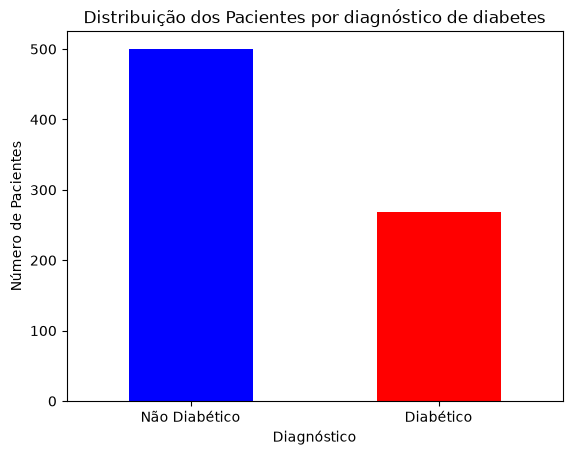

In [3]:
df["Diabetic"].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.xlabel('Diagnóstico')
plt.ylabel('Número de Pacientes')
plt.title('Distribuição dos Pacientes por diagnóstico de diabetes')
plt.xticks(ticks=[0, 1], labels=['Não Diabético', 'Diabético'], rotation=0)
plt.show()

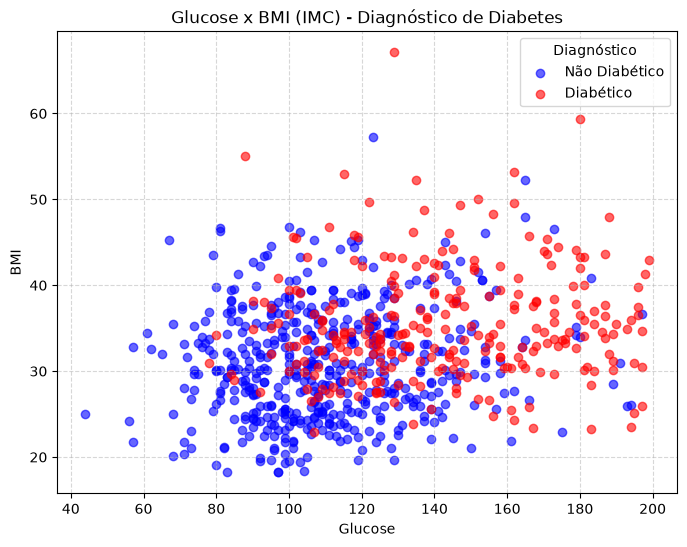

In [4]:
non_diabetic = df[df['Diabetic'] == 0]
diabetic = df[df['Diabetic'] == 1]

plt.figure(figsize=(8, 6))
plt.scatter(non_diabetic['Glucose'], non_diabetic['BMI'], color='blue', label='Não Diabético', alpha=0.6)
plt.scatter(diabetic['Glucose'], diabetic['BMI'], color='red', label='Diabético', alpha=0.6)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose x BMI (IMC) - Diagnóstico de Diabetes')
plt.legend(title='Diagnóstico')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Separando os dados em treino (70%) e teste (30%):

In [5]:
X = df[['Glucose', 'BMI']]
y = df['Diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Amostras de treino: {len(X_train)}")
print(f"Amostras de teste: {len(X_test)}")

Amostras de treino: 537
Amostras de teste: 231


Treinando o modelo de Regressão Logística:

In [6]:
log_model = LogisticRegression(max_iter=14000, random_state=42)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

Acurácia no conjunto de teste: 0.7446


Avaliando com relatório de classificação detalhado e matriz de confusão:

In [7]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       151
           1       0.65      0.56      0.60        80

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.71       231
weighted avg       0.74      0.74      0.74       231

Matriz de Confusão:
[[127  24]
 [ 35  45]]


Plotando a Curva ROC e calculando o AUC (*Area Under the Curve*):

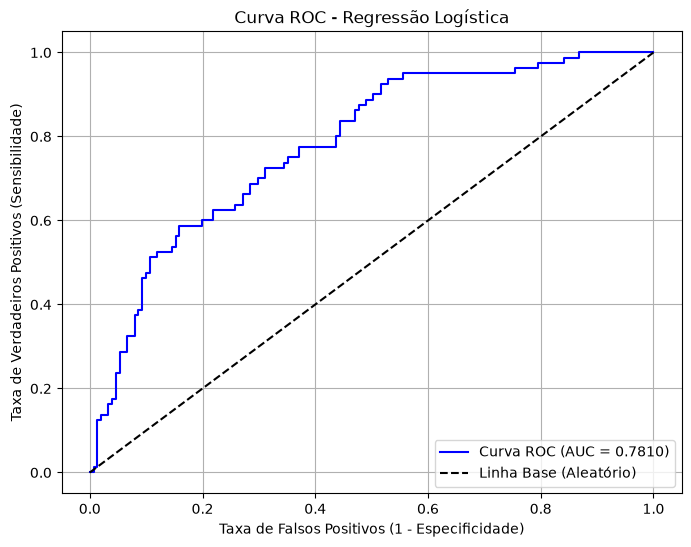

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])
auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Linha Base (Aleatório)')
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
plt.title('Curva ROC - Regressão Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [9]:
X_train_const = sm.add_constant(X_train) # Adiciona o intercepto (constante) para o statsmodels

# Instancia e ajusta a Regressão Logística por Máxima Verossimilhança
logit_model = sm.Logit(y_train, X_train_const) 
result = logit_model.fit()

print(result.summary()) # Exibe o resumo estatístico contendo parâmetros, erros-padrão, estatística z e p-valores

Optimization terminated successfully.
         Current function value: 0.464826
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Diabetic   No. Observations:                  537
Model:                          Logit   Df Residuals:                      534
Method:                           MLE   Df Model:                            2
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.2821
Time:                        20:08:07   Log-Likelihood:                -249.61
converged:                       True   LL-Null:                       -347.71
Covariance Type:            nonrobust   LLR p-value:                 2.492e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.3447      0.849    -11.013      0.000     -11.008      -7.682
Glucose        0.0430      0.

### Com base no resumo estatístico, podemos concluir o seguinte:

#### 1. Teste de Significância Global do Modelo
* Considerando a hipótese nula $H_0$ de que todos os coeficientes das variáveis explicativas do modelo são iguais a zero simultaneamente ($\beta_{\text{Glucose}} = 0 \quad \text{e} \quad \beta_{\text{BMI}} = 0$), obtivemos um **LLR p-value ($2.492 \times 10^{-43}$)**, e como esse valor é muito menor que $0.05$ rejeitamos a hipótese nula global ($H_0$), a favor da hipótese alternativa $H_1$ de que pelo menos um dos coeficientes $\beta_j \neq 0$. Concluímos, então, que o conjunto das variáveis `Glucose` e `BMI` possui efeito estatisticamente significante para prever o diagnóstico de diabetes.
* **Pseudo R-squared ($0.2821$):** O valor de McFadden indica um bom ajuste do modelo aos dados para problemas de classificação logística. (valores entre 0.20 e 0.40 indicam um ajuste muito forte e altamente satisfatório do modelo aos dados.)

---

#### 2. Testes de Hipótese dos Parâmetros Individuais

Para cada parâmetro $\beta_j$, avalia-se $H_0 : \beta_j = 0$ (a variável $X_j$ associada a $\beta_j$ não afeta o resultado) contra $H_1 : \beta_j \neq 0$:

Como ambas as variáveis apresentam **p-valor (P>|z|) < 0.05**, rejeitamos $H_0$ e concluímos que tanto a **Glicose** quanto o **IMC** são preditores estatisticamente significantes no modelo.

---

#### 3. Interpretação dos Efeitos (Razão de Chances / Odds Ratio)
* **Glicose ($\beta = 0.0430$):** Para cada unidade a mais de glicose no sangue (mantendo o IMC constante), a chance (*odds*) de diagnóstico de diabetes aumenta em aproximadamente $e^{0.0430} \approx 1.044$ (**+4,4%**).
* **IMC ($\beta = 0.1012$):** Para cada ponto adicional no IMC (mantendo a glicose constante), a chance de diagnóstico de diabetes aumenta em $e^{0.1012} \approx 1.106$ (**+10,6%**).

## 12. Exemplo prático simples com Gradiente Descendente

Aqui, será desenvolvido um exemplo semelhante ao exemplo da seção anterior, mas sem dividir em treino e teste e utilizando o método do Gradiente Descendente descrito em **5**.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
data_path = Path("../data/iris.csv")
df = pd.read_csv(data_path, usecols=['PetalLengthCm', 'PetalWidthCm', 'Species'])
df = df[df["Species"].isin(["Iris-setosa", "Iris-versicolor"])]
df.head()

,PetalLengthCm,PetalWidthCm,Species
0,1.4,0.2,Iris-setosa
1,1.4,0.2,Iris-setosa
2,1.3,0.2,Iris-setosa
3,1.5,0.2,Iris-setosa
4,1.4,0.2,Iris-setosa


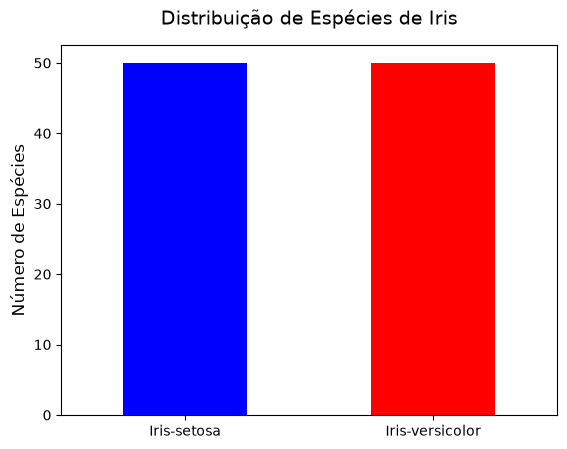

In [12]:
df['Species'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.xticks(ticks=[0, 1], labels=['Iris-setosa', 'Iris-versicolor'], rotation=0)
plt.title('Distribuição de Espécies de Iris', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Número de Espécies', fontsize=12)
plt.show()

In [13]:
X = df[["PetalLengthCm", "PetalWidthCm"]].to_numpy()
Y = df['Species'].astype('category').cat.codes.to_numpy()

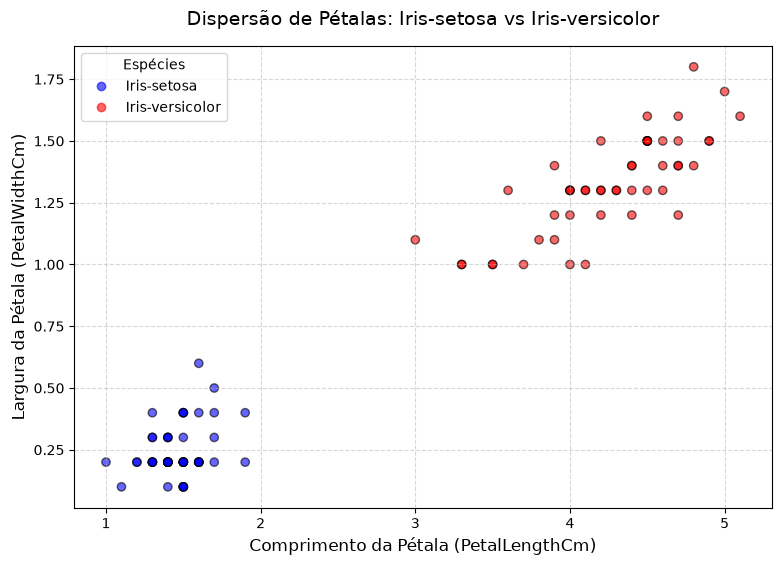

In [14]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['PetalLengthCm'], df['PetalWidthCm'], c=Y, cmap='bwr', alpha=0.6, edgecolors='k')
plt.title('Dispersão de Pétalas: Iris-setosa vs Iris-versicolor', fontsize=14, pad=15)
plt.xlabel("Comprimento da Pétala (PetalLengthCm)", fontsize=12)
plt.ylabel('Largura da Pétala (PetalWidthCm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(handles=scatter.legend_elements()[0], labels=["Iris-setosa", "Iris-versicolor"], title="Espécies")
plt.show()

A função sigmoide para cálculo das probabilidades previstas será definida.

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

A função de custo será definida.

In [16]:
def cost_function(x, y, b, b0):
    n = len(x)
    cost_sum = 0

    for i in range(n):
        z = b0 + np.dot(b, x[i])
        y_pred = sigmoid(z)

        # para evitar log(0), limitando a probabilidade no intervalo [1e-15, 1 - 1e-15]
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

        cost_sum += y[i] * np.log(y_pred) + (1 - y[i]) * np.log(1 - y_pred)

    return (-1 / n) * cost_sum

Agora, o vetor gradiente será definido. 

$X$ é uma matriz com $i$ observações e $j$ features, sem a variável target $Y$

$Y$ é a variável target relacionada a $X$

$b$ é um vetor que representa os coeficientes em $z$, com mesmo tamanho que a quantidade de colunas em $X$ (features)

$b0$ é um valor que representa o intercepto em $z$

In [17]:
def gradient_vector(x, y, b, b0):
    n = len(x)
    sum_dj_db = np.zeros_like(b)
    sum_dj_db0 = 0

    for i in range(n):
        z = b0 + np.dot(b, x[i])
        y_pred = sigmoid(z)

        sum_dj_db0 += (y_pred - y[i])
        for j in range(len(b)):
            sum_dj_db[j] += (y_pred - y[i]) * x[i, j]

    dj_db0 = (1 / n) * sum_dj_db0
    dj_db = (1 / n) * sum_dj_db
    return dj_db0, dj_db

Por fim, definimos a função gradiente descendente, com os parâmetros $b$ e $b0$ sendo arbitrariamente inicializados com valor $0$.

In [18]:
def gradient_descent(x, y, learning_rate, iterations):
    b = np.zeros(x.shape[1])
    b0 = 0

    costs = [cost_function(x, y, b, b0)]
    print(f"Iteração: 0 - Custo: {costs[0]} - b0: {b0} - b: {b}")

    for i in range(iterations):
        dj_db0, dj_db = gradient_vector(x, y, b, b0)

        b0 = b0 - learning_rate * dj_db0
        b = b - learning_rate * dj_db

        cost = cost_function(x, y, b, b0)
        costs.append(cost)

        if (i + 1) % 1000 == 0:
            print(f"Iteração: {i + 1} - Custo: {cost} - b0: {b0} - b: {b}")

    return b, b0, costs

In [19]:
def predict(x, b, b0):
    n = len(x)
    y_preds = np.zeros(n)

    for i in range(n):
        z = b0 + np.dot(b, x[i])
        y_pred = sigmoid(z)

        y_preds[i] = 1 if y_pred >= 0.5 else 0

        print(f"Entrada: {x[i]} - Probabilidade de ser Iris-versicolor: {y_pred:.4f} - Classificação: {'Iris-versicolor' if y_preds[i] == 1 else 'Iris-setosa'}")

    return y_preds

Agora, utilizamos o gradiente descendente para aprendemos os melhores parâmetros para obter as probabilidades de forma a classificar corretamente como 0 ou 1.

In [20]:
learning_rate = 0.01
iterations = 14000

b, b0, costs = gradient_descent(X, Y, learning_rate, iterations)

Iteração: 0 - Custo: 0.693147180559946 - b0: 0 - b: [0. 0.]
Iteração: 1000 - Custo: 0.32602896207705095 - b0: -1.4315466265373273 - b: [0.54452146 0.67198335]
Iteração: 2000 - Custo: 0.21226501188770033 - b0: -2.394466466591343 - b: [0.75712089 1.06090986]
Iteração: 3000 - Custo: 0.15533849398481628 - b0: -3.07539933683621 - b: [0.91574918 1.33709968]
Iteração: 4000 - Custo: 0.12211901703953652 - b0: -3.595388506696917 - b: [1.0408333  1.54837732]
Iteração: 5000 - Custo: 0.10058283087397349 - b0: -4.013895678930082 - b: [1.1437192  1.71857353]
Iteração: 6000 - Custo: 0.08555701259132797 - b0: -4.3633198178473105 - b: [1.23100472 1.86075498]
Iteração: 7000 - Custo: 0.07449945441491444 - b0: -4.662950556519979 - b: [1.30678363 1.98272583]
Iteração: 8000 - Custo: 0.06602883477066104 - b0: -4.925100335329303 - b: [1.37374626 2.08947584]
Iteração: 9000 - Custo: 0.05933439847274365 - b0: -5.158068885651831 - b: [1.43374658 2.18437184]
Iteração: 10000 - Custo: 0.05391056616902817 - b0: -5.367

No gráfico, é possível observar que a função de custo diminui conforme as iterações do gradiente descendente para melhorar os parâmetros $b$ e $b0$.

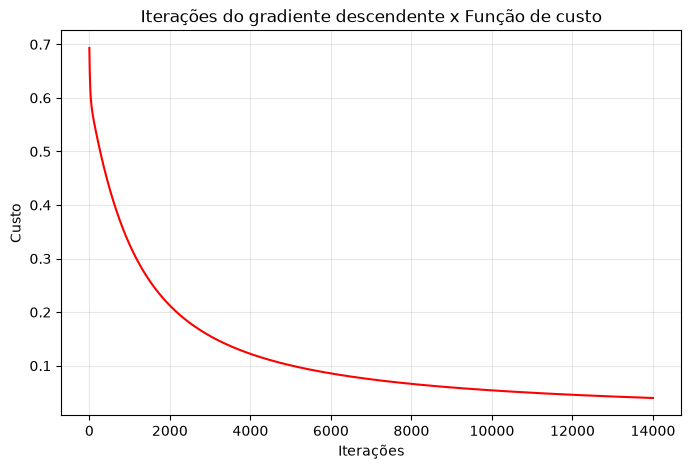

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(costs)), costs, color="red")
plt.xlabel("Iterações")
plt.ylabel("Custo")
plt.title("Iterações do gradiente descendente x Função de custo")
plt.grid(True, which="both", alpha=0.3)
plt.show()

Como já mencionado, na Regressão Logística Binária, a classe predita $\hat{y}$ é determinada a partir de um **limiar de decisão** (*decision threshold*) aplicado à probabilidade estimada $\sigma(z) = P(Y=1|X)$. 

Por padrão, adota-se o limiar de **$0.5$**, o que significa atribuir a classe positiva ($1$) quando a probabilidade for maior ou igual a $50\%$:

$$\hat{y} = \begin{cases} 1 & \text{se } \sigma(z) \ge 0.5 \\ 0 & \text{se } \sigma(z) < 0.5 \end{cases}$$

Como a função sigmoide é estritamente crescente e satisfaz $\sigma(0) = 0.5$, a transição entre as classes ocorre exatamente na região em que o argumento linear $z = 0$:

$$z = w_1 x_1 + w_2 x_2 + b = 0$$

(estou considerando apenas dois coeficientes e esses coeficientes, $w$, como sendo do vetor $b$ e o intercepto $b$ como $b0$)

Isso gera uma **fronteira de decisão linear** no plano de atributos $2\text{D}$. Para visualizar essa reta em um gráfico com $x_1$ no eixo horizontal e $x_2$ no eixo vertical, isola-se $x_2$ na equação:

$$x_2 = -\left(\frac{w_1}{w_2}\right) x_1 - \frac{b}{w_2}$$


* **Pontos onde $w_1 x_1 + w_2 x_2 + b > 0$:** Resultam em $\sigma(z) > 0.5$ e são classificados como **Classe 1**
* **Pontos onde $w_1 x_1 + w_2 x_2 + b < 0$:** Resultam em $\sigma(z) < 0.5$ e são classificados como **Classe 0**
* **Linha $x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$:** É a linha exata de incerteza do modelo, $w_1 x_1 + w_2 x_2 + b = 0$, que representa $\sigma(0) = 0.5$, a probabilidade prevista de $50\%$

No gráfico, é possível observar a fronteira de decisão obtida, que separa as classes corretamente.

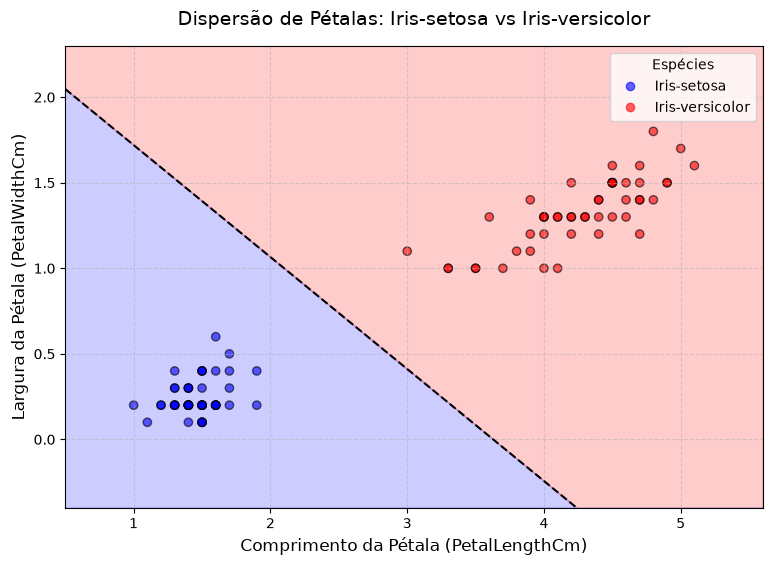

In [22]:
# Considerando uma reta y = mx + c
m = -b[0] / b[1]
c = -b0 / b[1]

xmin, xmax = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
xl = np.linspace(xmin, xmax, 100)
yl = m * xl + c
ymin, ymax = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

plt.figure(figsize=(9, 6))
plt.plot(xl, yl, ls='--', color='black', label='Linha de Decisão')
plt.fill_between(xl, yl, ymin, color='blue', alpha=0.2, label='Região: Iris-setosa')
plt.fill_between(xl, yl, ymax, color='red', alpha=0.2, label='Região: Iris-versicolor')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

scatter = plt.scatter(df['PetalLengthCm'], df['PetalWidthCm'], c=Y, cmap='bwr', alpha=0.6, edgecolors='k')
plt.title('Dispersão de Pétalas: Iris-setosa vs Iris-versicolor', fontsize=14, pad=15)
plt.xlabel("Comprimento da Pétala (PetalLengthCm)", fontsize=12)
plt.ylabel('Largura da Pétala (PetalWidthCm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(handles=scatter.legend_elements()[0], labels=["Iris-setosa", "Iris-versicolor"], title="Espécies")
plt.show()

No gráfico, é possível observar a curva sigmoide plotada em conjunto com os pontos do conjunto de dados.

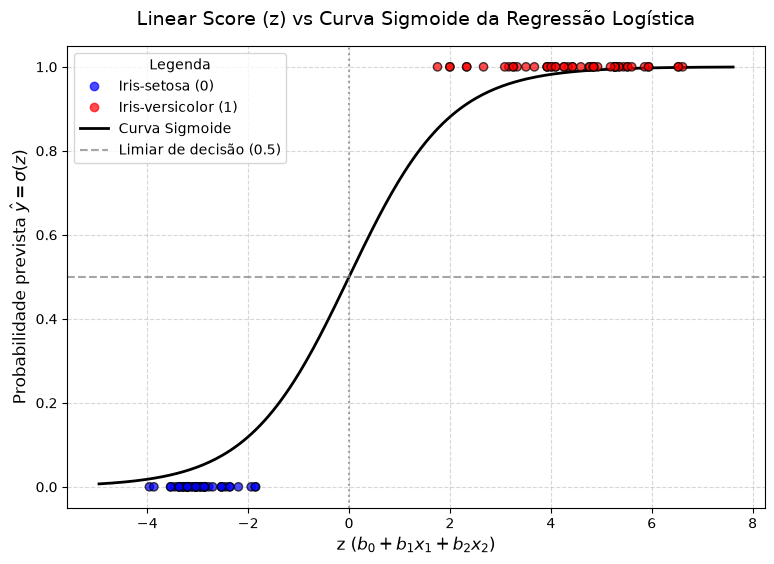

In [23]:
z_samples = b0 + np.dot(X, b)
x_z_samples = np.linspace(z_samples.min() - 1, z_samples.max() + 1, 300)
y_sigmoid_curve = sigmoid(x_z_samples)

plt.figure(figsize=(9, 6))
sigmoid_line, = plt.plot(x_z_samples, y_sigmoid_curve, color='black', linewidth=2, label=r'Sigmoid Function: $\sigma(z)$')
threshold_line = plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Decision Threshold (0.5)')
plt.axvline(0, color='gray', linestyle=':', alpha=0.7)
scatter = plt.scatter(z_samples, Y, c=Y, cmap='bwr', alpha=0.7, edgecolors='k', zorder=3)
plt.title('Linear Score (z) vs Curva Sigmoide da Regressão Logística', fontsize=14, pad=15)
plt.xlabel('z ($b_0 + b_1 x_1 + b_2 x_2$)', fontsize=12)
plt.ylabel(r'Probabilidade prevista $\hat{y} = \sigma(z)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(handles=scatter.legend_elements()[0] + [sigmoid_line, threshold_line], labels=["Iris-setosa (0)", "Iris-versicolor (1)", "Curva Sigmoide", "Limiar de decisão (0.5)"], title="Legenda")
plt.show()

Teste simples com todos os dados para verificar o aprendizado (eu sei que o correto deveria ser separar em treino e teste).

In [24]:
predictions = predict(X, b, b0)
accuracy = np.mean(predictions == Y) * 100
print(f"Acurácia do modelo de Regressão Logística: {accuracy:.2f}%")

Entrada: [1.4 0.2] - Probabilidade de ser Iris-versicolor: 0.0391 - Classificação: Iris-setosa
Entrada: [1.4 0.2] - Probabilidade de ser Iris-versicolor: 0.0391 - Classificação: Iris-setosa
Entrada: [1.3 0.2] - Probabilidade de ser Iris-versicolor: 0.0333 - Classificação: Iris-setosa
Entrada: [1.5 0.2] - Probabilidade de ser Iris-versicolor: 0.0458 - Classificação: Iris-setosa
Entrada: [1.4 0.2] - Probabilidade de ser Iris-versicolor: 0.0391 - Classificação: Iris-setosa
Entrada: [1.7 0.4] - Probabilidade de ser Iris-versicolor: 0.1003 - Classificação: Iris-setosa
Entrada: [1.4 0.3] - Probabilidade de ser Iris-versicolor: 0.0498 - Classificação: Iris-setosa
Entrada: [1.5 0.2] - Probabilidade de ser Iris-versicolor: 0.0458 - Classificação: Iris-setosa
Entrada: [1.4 0.2] - Probabilidade de ser Iris-versicolor: 0.0391 - Classificação: Iris-setosa
Entrada: [1.5 0.1] - Probabilidade de ser Iris-versicolor: 0.0359 - Classificação: Iris-setosa
Entrada: [1.5 0.2] - Probabilidade de ser Iris-ver

Teste com dados novos: Iris-versicolor e Iris-setosa, respectivamente.

In [25]:
predict(np.array([[4.2, 1.3]]), b, b0)

Entrada: [4.2 1.3] - Probabilidade de ser Iris-versicolor: 0.9861 - Classificação: Iris-versicolor


array([1.])

In [26]:
predict(np.array([[1.5, 0.3]]), b, b0)

Entrada: [1.5 0.3] - Probabilidade de ser Iris-versicolor: 0.0583 - Classificação: Iris-setosa


array([0.])

## 13. Conclusão

A Regressão Logística consolida-se como um dos pilares fundamentais da aprendizagem estatística e do aprendizado de máquina supervisionado. Ao combinar a transformação não linear da função sigmoide com a linearidade do log-odds, ela resolve elegantemente as limitações da regressão linear tradicional em tarefas de classificação binária.

Vimos que a estimação de seus parâmetros se apoia na Máxima Verossimilhança e na convexidade da Entropia Cruzada Binária, permitindo uma otimização estável via Gradiente Descendente. Além disso, técnicas como a regularização (Lasso e Ridge) e a análise rigorosa de métricas (como a Matriz de Confusão e a Curva ROC-AUC) garantem que o modelo mantenha alta capacidade de generalização e interpretabilidade em cenários reais. Também foi possível observar sua relação com a estrutura base das Redes Neurais.